# temporal predictions 

using encoders instead of sparse embedding settling loop in predictive coding to do autoregressive prediciton/generation task. Architecture of predictive coding based model in temporal_predictive_coding meant that pixel shfits resulted in compeltely different neurons firing in the predictive coding model, therefore resulting in chaotic embeddings and minimum cosine similarity between consecutive frames was 50% which isn't very good. Also 31% of the embedding was pure noise. This meant it was an impossible task to actually have the temporalNN learn anything beacuse the embeddings were inherently chaotic. Now use encoder instead. 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [15]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

In [16]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    if I.ndim == 4:
        previous_num_channels = I.shape[1]
    elif I.ndim == 3:
        previous_num_channels = I.shape[0]
    else:
        previous_num_channels = 1
    r = []
    encoders = []
    deconvs = []
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        encoder = nn.Conv2d(previous_num_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False)
        nn.init.kaiming_normal_(encoder.weight, nonlinearity="linear")
        encoders.append(encoder)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs, encoders

In [17]:
class ConvGRUCell(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv_zr = nn.Conv2d(channels * 2, channels * 2, kernel_size, padding=padding)
        self.conv_h = nn.Conv2d(channels * 2, channels, kernel_size, padding=padding)

    def forward(self, x, h):
        if h is None:
            h = torch.zeros_like(x)
        zr = torch.sigmoid(self.conv_zr(torch.cat([x, h], dim=1)))
        z, r = zr.chunk(2, dim=1)
        h_tilde = torch.tanh(self.conv_h(torch.cat([x, r * h], dim=1)))
        return (1.0 - z) * h + z * h_tilde


class TemporalConvRNN(nn.Module):
    def __init__(self, r, delta_scale=0.1):
        super().__init__()
        self.delta_scale = delta_scale
        self.cells = nn.ModuleList()
        self.readouts = nn.ModuleList()
        for ri in r:
            ch = ri.shape[1]
            self.cells.append(ConvGRUCell(ch))
            readout = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
            nn.init.zeros_(readout.weight)
            nn.init.zeros_(readout.bias)
            self.readouts.append(readout)

    def init_hidden(self, r_like):
        return [torch.zeros_like(ri) for ri in r_like]

    def forward(self, r_in, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(r_in)
        r_pred, h_new, deltas = [], [], []
        for cell, readout, x, h in zip(self.cells, self.readouts, r_in, hidden):
            h_t = cell(x, h)
            delta = self.delta_scale * torch.tanh(readout(h_t))
            deltas.append(delta)
            r_pred.append(x + delta)
            h_new.append(h_t)
        return r_pred, h_new, deltas

TemporalNN = TemporalConvRNN


Training Loop

In [18]:
def encode_I(I, encoders, num_layers):
    r = [encoders[0](I)]
    for i in range(1, num_layers):
        r.append(encoders[i](r[i - 1]))
    return r


def _perturb_r(rs, noise_std):
    if noise_std is None or noise_std <= 0:
        return rs
    return [ri + torch.randn_like(ri) * noise_std for ri in rs]


def _cosine_slowness(r_curr, r_prev):
    loss = 0.0
    for rc, rp in zip(r_curr, r_prev):
        a = rc.reshape(1, -1)
        b = rp.reshape(1, -1)
        loss = loss + (1.0 - F.cosine_similarity(a, b).squeeze())
    return loss / len(r_curr)


def _set_requires_grad(modules, flag):
    for m in modules:
        for p in m.parameters():
            p.requires_grad = flag


def _update_temporal_params(temporal_nn, lr_u, lambda_u, max_grad_norm=1.0):
    torch.nn.utils.clip_grad_norm_(temporal_nn.parameters(), max_grad_norm)
    with torch.no_grad():
        for param in temporal_nn.parameters():
            if param.grad is not None:
                param -= lr_u * (param.grad + lambda_u * param)
                param.grad = None


def train_loop(I_curr, r_prev1, r_curr, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, hidden=None, r_noise_std=0.0, lambda_slow=0.1, delta_loss_weight=20.0, train_ae=True, train_gru=False):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    has_prev = r_prev1 is not None
    if r_prev1 is None:
        r_prev1 = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev1 = [ri.detach() for ri in r_prev1]

    if hidden is None:
        hidden = temporal_nn.init_hidden(r_curr)
    else:
        hidden = [hi.detach() for hi in hidden]

    h_new = hidden
    r_pred = None
    deltas = None
    delta_stats = (0.0, 0.0)
    recon_loss = torch.zeros((), device=I_curr.device)
    slow_raw = torch.zeros((), device=I_curr.device)

    for out_epoch in range(num_epochs_outer):
        if train_ae:
            r_curr = encode_I(I_curr, encoders, num_layers)
        else:
            with torch.no_grad():
                r_curr = encode_I(I_curr, encoders, num_layers)

        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        recon_loss = (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[0] ** 2)
        for j in range(1, num_layers):
            e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            recon_loss = recon_loss + (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[j] ** 2)

        if has_prev:
            slow_raw = _cosine_slowness(r_curr, r_prev1)

        total_loss = torch.zeros((), device=I_curr.device)
        if train_ae:
            total_loss = total_loss + recon_loss
            if has_prev and lambda_slow > 0:
                total_loss = total_loss + lambda_slow * slow_raw

        if train_gru and has_prev:
            r_in = _perturb_r([ri.detach() for ri in r_prev1], r_noise_std)
            h_in = [hi.detach() for hi in hidden]
            r_pred, h_new, deltas = temporal_nn(r_in, h_in)
            for j in range(num_layers):
                delta_target = (r_curr[j] - r_prev1[j]).detach()
                total_loss = total_loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")

        if train_ae:
            for j in range(num_layers):
                encoders[j].zero_grad()
                deconvs[j].zero_grad()
        if train_gru:
            temporal_nn.zero_grad()

        if total_loss.requires_grad:
            total_loss.backward()

        with torch.no_grad():
            if has_prev:
                a_norm = sum(torch.norm(r_curr[j] - r_prev1[j]).item() for j in range(num_layers))
            else:
                a_norm = 0.0
            d_norm = sum(torch.norm(d).item() for d in deltas) if deltas is not None else 0.0
            delta_stats = (d_norm, a_norm)
            if train_ae:
                for j in range(num_layers):
                    if deconvs[j].weight.requires_grad and deconvs[j].weight.grad is not None:
                        deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                        deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                        deconvs[j].weight.grad = None
                    if encoders[j].weight.requires_grad and encoders[j].weight.grad is not None:
                        encoders[j].weight -= lr_u * (encoders[j].weight.grad + lambda_u * encoders[j].weight)
                        encoders[j].weight.grad = None
        if train_gru:
            _update_temporal_params(temporal_nn, lr_u, lambda_u)

    slow_term = (lambda_slow * slow_raw) if has_prev and lambda_slow > 0 else torch.zeros(())
    loss_stats = {
        "recon": float(recon_loss.detach()),
        "slow_raw": float(slow_raw.detach()),
        "slow": float(slow_term.detach()),
    }
    h_out = [hi.detach() for hi in h_new]
    return r_curr, r_pred, h_out, delta_stats, loss_stats


sequential training

In [19]:
def rollout_temporal_loss(r_in, hidden, r_targets, temporal_nn, sigma_2, lr_u, lambda_u, r_noise_std=0.0, delta_loss_weight=20.0):
    x = _perturb_r([ri.detach() for ri in r_in], r_noise_std)
    h = [hi.detach() for hi in hidden]
    loss = 0.0
    for target in r_targets:
        r_pred, h, deltas = temporal_nn(x, h)
        for j in range(len(r_pred)):
            delta_target = (target[j] - x[j]).detach()
            loss = loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")
        x = r_pred
    temporal_nn.zero_grad()
    loss.backward()
    _update_temporal_params(temporal_nn, lr_u, lambda_u)
    return float(loss.detach())


def train_video_sequence(sequence, r_curr_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, r_noise_std=0.0, ss_p=0.0, rollout_k=1, lambda_slow=0.1, delta_loss_weight=20.0, train_ae=True, train_gru=False):
    r_prev1 = None
    hidden = None
    r_curr = r_curr_init
    r_sequence = []
    h_sequence = []
    delta_norms = []
    dr_norms = []
    recon_vals = []
    slow_raw_vals = []
    slow_vals = []

    for i, image in enumerate(sequence):
        I_curr = image.float()

        r_curr, r_pred, hidden, (d_norm, a_norm), loss_stats = train_loop(
            I_curr, r_prev1, r_curr,
            alpha, lambda_u, lr_r, lr_u, sigma_2,
            num_epochs_outer, num_epochs_inner, num_layers,
            deconvs, encoders, temporal_nn,
            hidden=hidden,
            r_noise_std=r_noise_std,
            lambda_slow=lambda_slow,
            delta_loss_weight=delta_loss_weight,
            train_ae=train_ae,
            train_gru=train_gru,
        )

        recon_vals.append(loss_stats["recon"])
        slow_raw_vals.append(loss_stats["slow_raw"])
        slow_vals.append(loss_stats["slow"])

        if r_prev1 is not None and a_norm > 0:
            delta_norms.append(d_norm)
            dr_norms.append(a_norm)

        r_sequence.append([ri.detach().clone() for ri in r_curr])
        h_sequence.append([hi.detach().clone() for hi in hidden])

        if train_gru and r_prev1 is not None and r_pred is not None and np.random.rand() < ss_p:
            r_prev1 = [ri.detach().clone() for ri in r_pred]
        else:
            r_prev1 = [ri.detach() for ri in r_curr]

    if train_gru and rollout_k > 1 and len(r_sequence) >= 1 + rollout_k:
        for t in range(1, len(r_sequence) - rollout_k + 1):
            rollout_temporal_loss(
                r_sequence[t - 1],
                h_sequence[t - 1],
                r_sequence[t:t + rollout_k],
                temporal_nn,
                sigma_2,
                lr_u,
                lambda_u,
                r_noise_std=r_noise_std,
                delta_loss_weight=delta_loss_weight,
            )

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    return r_sequence, {
        "delta_norm": mean_delta,
        "dr_norm": mean_dr,
        "ratio": ratio,
        "recon": sum(recon_vals) / max(len(recon_vals), 1),
        "slow_raw": sum(slow_raw_vals) / max(len(slow_raw_vals), 1),
        "slow": sum(slow_vals) / max(len(slow_vals), 1),
    }


validation


In [20]:
def validate_heirarchical(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders,temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []
    I_prev = None

    delta_norms = []
    dr_norms = []
    mse_vs_curr = []
    mse_vs_prev = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())
                mse_vs_curr.append(torch.mean((I_hat - I_curr) ** 2).item())
                if I_prev is not None:
                    mse_vs_prev.append(torch.mean((I_hat - I_prev) ** 2).item())

            r_curr = encode_I(I_curr, encoders, num_layers)

            if t >= 1:
                d_norm = 0.0
                a_norm = 0.0
                for i in range(num_layers):
                    d_norm += torch.norm(deltas[i]).item()
                    a_norm += torch.norm(r_curr[i] - r_prev1_use[i]).item()
                delta_norms.append(d_norm)
                dr_norms.append(a_norm)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]
        I_prev = I_curr.detach().clone()

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    mean_mse_curr = sum(mse_vs_curr) / max(len(mse_vs_curr), 1)
    mean_mse_prev = sum(mse_vs_prev) / max(len(mse_vs_prev), 1)
    motion_gap = mean_mse_curr - mean_mse_prev
    print(f"Identity check | ||delta||={mean_delta:.6f}  ||r_t-r_(t-1)||={mean_dr:.6f}  ratio={ratio:.4f}  delta_scale={temporal_nn.delta_scale}")
    # COPY/MOTION only meaningful once grounded preds look like digits (low MSE)
    if mean_mse_curr < 0.1:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  MSE(pred,true_(t-1))={mean_mse_prev:.6f}  gap={motion_gap:+.6f}  {'COPY' if motion_gap > 0 else 'MOTION'}")
    else:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  (skip COPY/MOTION — preds not digit-like yet)")

    return mse, mse_per_frame, true_frames, pred_frames, r_curr, motion_gap, ratio


def validate_recon(seq, deconvs, encoders, num_layers):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    trues, recons = [], []
    with torch.no_grad():
        for t in range(seq.shape[0]):
            I = seq[t] - seq[t].mean()
            if I.ndim == 3:
                I = I.unsqueeze(0)
            r = encode_I(I, encoders, num_layers)
            I_hat = f(deconvs[0](r[0]))
            trues.append(I.detach().clone())
            recons.append(I_hat.detach().clone())
    trues = torch.stack(trues, dim=0)
    recons = torch.stack(recons, dim=0)
    mse = torch.mean((trues - recons) ** 2)
    return mse, trues, recons




def _flat_r(r_list):
    return torch.cat([ri.reshape(-1) for ri in r_list])


def _pair_stats(ra, rb):
    a, b = _flat_r(ra), _flat_r(rb)
    cos = F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()
    rel = (torch.norm(a - b) / (torch.norm(a) + 1e-8)).item()
    abs_dist = torch.norm(a - b).item()
    return cos, rel, abs_dist


def diagnose_latent_smoothness(seq, unrelated_frames, encoders, num_layers, max_unrelated_pairs=40, label=""):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    tag = label or "encoder"

    print("\n" + "=" * 60)
    print(f"B. Latent smoothness [{tag}]")
    print("=" * 60)

    rs = []
    with torch.no_grad():
        I0 = seq[0]
        if I0.ndim == 3:
            I0 = I0.unsqueeze(0)
        I0 = I0 - I0.mean()
        ra = encode_I(I0, encoders, num_layers)
        rb = encode_I(I0, encoders, num_layers)
        same_cos, _, _ = _pair_stats(ra, rb)
        print(f"Same-frame cos={same_cos:.4f}  (must be 1.0)")
        for t in range(T):
            I_curr = seq[t]
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)
            I_curr = I_curr - I_curr.mean()
            rs.append([ri.detach().clone() for ri in encode_I(I_curr, encoders, num_layers)])

    cons_cos, cons_rel, cons_abs = [], [], []
    print(f"\n{'t':>4}  {'cos(r_t,r_t-1)':>14}  {'||dr||/||r_t||':>14}  {'||dr||':>10}")
    for t in range(1, T):
        cos, rel, abs_d = _pair_stats(rs[t], rs[t - 1])
        cons_cos.append(cos)
        cons_rel.append(rel)
        cons_abs.append(abs_d)
        print(f"{t:4d}  {cos:14.4f}  {rel:14.4f}  {abs_d:10.4f}")

    u_rs = []
    with torch.no_grad():
        for I in unrelated_frames:
            I_u = I.float()
            if I_u.ndim == 3:
                I_u = I_u.unsqueeze(0)
            I_u = I_u - I_u.mean()
            u_rs.append([ri.detach().clone() for ri in encode_I(I_u, encoders, num_layers)])

    un_cos, un_rel, un_abs = [], [], []
    n_u = len(u_rs)
    pairs = [(i, j) for i in range(n_u) for j in range(i + 1, n_u)]
    if len(pairs) > max_unrelated_pairs:
        idx = torch.randperm(len(pairs))[:max_unrelated_pairs].tolist()
        pairs = [pairs[k] for k in idx]
    for i, j in pairs:
        cos, rel, abs_d = _pair_stats(u_rs[i], u_rs[j])
        un_cos.append(cos)
        un_rel.append(rel)
        un_abs.append(abs_d)

    m_cc, m_cr, m_ca = np.mean(cons_cos), np.mean(cons_rel), np.mean(cons_abs)
    m_uc, m_ur, m_ua = np.mean(un_cos), np.mean(un_rel), np.mean(un_abs)
    frac_rel = m_cr / (m_ur + 1e-8)
    frac_abs = m_ca / (m_ua + 1e-8)

    print(f"\nConsecutive ({tag}):  cos={m_cc:.4f}  rel={m_cr:.4f}  ||dr||={m_ca:.4f}")
    print(f"Unrelated frames:      cos={m_uc:.4f}  rel={m_ur:.4f}  ||dr||={m_ua:.4f}")
    print(f"consec/unrelated:      rel={frac_rel:.3f}  abs={frac_abs:.3f}")
    if frac_rel > 0.7:
        print("VERDICT: NON-SMOOTH — consecutive ≈ unrelated.")
    elif frac_rel > 0.4:
        print("VERDICT: moderately jumpy.")
    else:
        print("VERDICT: usable — consecutive clearly closer than unrelated.")
    return {
        "cons_cos": m_cc, "cons_rel": m_cr, "cons_abs": m_ca,
        "un_cos": m_uc, "un_rel": m_ur, "un_abs": m_ua,
        "frac_rel": frac_rel, "frac_abs": frac_abs, "tag": tag,
    }



In [21]:
def validate_heirarchical_long(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn, split_point=10):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

            if t >= split_point:
                I_obs = pred_frames[t - 1] - pred_frames[t - 1].mean()
                if I_obs.ndim == 3:
                    I_obs = I_obs.unsqueeze(0)
                if t == split_point:
                    sat_true = (I_curr.abs() > 0.99).float().mean().item()
                    sat_sub = (I_obs.abs() > 0.99).float().mean().item()
                    print(f"t={t} saturation | true: {sat_true:.4f} | substitute: {sat_sub:.4f}")
            else:
                I_obs = I_curr

            r_curr = encode_I(I_obs, encoders, num_layers)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr






In [22]:
def _plot_pairs(true_frames, other_frames, row2="Pred"):
    n_show = true_frames.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {t + 1}")
        axes[0, t].axis("off")
        axes[1, t].imshow(other_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"{row2} {t + 1}")
        axes[1, t].axis("off")
    plt.show()


def main():
    num_data = 20
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_ae_epochs = 15
    num_gru_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lambda_slow = 0.2
    delta_loss_weight = 100.0
    lr_r = 0.02
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2
    r_noise_std_start = 0.0
    r_noise_std_end = 0.05
    ss_p_start = 0.0
    ss_p_end = 0.4
    rollout_k = 4
    num_epochs_inner = 200
    num_epochs_outer = 1

    print("=" * 60)
    print(f"Stage A: {num_ae_epochs} AE epochs | Stage B: {num_gru_epochs} GRU epochs | {num_data} sequences")
    print(f"Cosine slowness λ={lambda_slow}  lr_U={lr_U}  lambda_u={lambda_u}")
    print("=" * 60)

    _, r_init, deconvs, encoders = make_variables(sequences[0][0], num_layers=num_layers)
    temporal_nn = TemporalConvRNN(r_init, delta_scale=1.0)
    print(f"delta_scale={temporal_nn.delta_scale}  grad_clip=1.0  delta_loss={delta_loss_weight}*mean")

    _unrelated = [input_data[i][0].float() / 255.0 for i in range(num_data, num_data + 8)]

    print("\n" + "#" * 60)
    print("STAGE A — train encoder + decoder only (recon + cosine slowness)")
    print("#" * 60)
    _set_requires_grad(encoders + deconvs, True)
    for p in temporal_nn.parameters():
        p.requires_grad = False

    for epoch in range(num_ae_epochs):
        epoch_recon, epoch_slow_raw, epoch_slow = [], [], []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn,
                r_noise_std=0.0, ss_p=0.0, rollout_k=1,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
                train_ae=True,
                train_gru=False,
            )
            epoch_recon.append(train_stats["recon"])
            epoch_slow_raw.append(train_stats["slow_raw"])
            epoch_slow.append(train_stats["slow"])

        recon_mse, true_frames, recon_frames = validate_recon(sequences[0], deconvs, encoders, num_layers)
        print(
            f"[A {epoch:03d}/{num_ae_epochs:03d}]  L_recon={sum(epoch_recon)/len(epoch_recon):.5f}  "
            f"L_slow_raw={sum(epoch_slow_raw)/len(epoch_slow_raw):.5f}  "
            f"λL_slow={sum(epoch_slow)/len(epoch_slow):.5f}  "
            f"recon MSE={float(recon_mse):.6f}"
        )
        if epoch % 5 == 0 or epoch == num_ae_epochs - 1:
            _plot_pairs(true_frames, recon_frames, row2="Recon")

    diagnose_latent_smoothness(
        sequences[0], _unrelated, encoders, num_layers,
        label="after stage A",
    )

    print("\n" + "#" * 60)
    print("STAGE B — freeze encoder + decoder, train GRU only")
    print("#" * 60)
    _set_requires_grad(encoders + deconvs, False)
    for p in temporal_nn.parameters():
        p.requires_grad = True

    for epoch in range(num_gru_epochs):
        frac = epoch / max(num_gru_epochs - 1, 1)
        r_noise_std = r_noise_std_start + (r_noise_std_end - r_noise_std_start) * frac
        ss_p = ss_p_start + (ss_p_end - ss_p_start) * frac
        epoch_ratios = []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn,
                r_noise_std=r_noise_std, ss_p=ss_p, rollout_k=rollout_k,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
                train_ae=False,
                train_gru=True,
            )
            epoch_ratios.append(train_stats["ratio"])

        train_ratio = sum(epoch_ratios) / max(len(epoch_ratios), 1)
        mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
            sequences[0], r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
        )
        print(
            f"[B {epoch:03d}/{num_gru_epochs:03d}]  r_noise={r_noise_std:.4f}  ss_p={ss_p:.3f}  "
            f"Next-frame MSE: {mse:.6f}  train_δ-ratio={train_ratio:.4f}  val_δ-ratio={val_ratio:.4f}"
        )
        if epoch % 5 == 0 or epoch == num_gru_epochs - 1:
            _plot_pairs(true_frames, pred_frames, row2="Pred")

    print("\nPost-train latent smoothness (frozen encoder):")
    diagnose_latent_smoothness(
        sequences[0], _unrelated, encoders, num_layers,
        label="after stage B",
    )

    val_seq = input_data[num_data].float() / 255.0
    recon_mse, true_recon, recon_frames = validate_recon(val_seq, deconvs, encoders, num_layers)
    print(f"Held-out grounded recon MSE: {float(recon_mse):.6f}")
    _plot_pairs(true_recon, recon_frames, row2="Recon")

    mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Validation  ->  Next-frame MSE: {mse:.6f}  δ-ratio={val_ratio:.4f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")
    _plot_pairs(true_frames, pred_frames, row2="Pred")

    temporal_nn.eval()
    mse_lr, mse_per_frame_lr, true_frames_lr, pred_frames_lr, _ = validate_heirarchical_long(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Long-run  ->  MSE: {mse_lr:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame_lr.tolist()]}")
    _plot_pairs(true_frames_lr, pred_frames_lr, row2="Pred")


Stage A: 15 AE epochs | Stage B: 20 GRU epochs | 20 sequences
Cosine slowness λ=0.2  lr_U=0.002  lambda_u=0.001
delta_scale=1.0  grad_clip=1.0  delta_loss=100.0*mean

############################################################
STAGE A — train encoder + decoder only (recon + cosine slowness)
############################################################
[A 000/015]  L_recon=0.10770  L_slow_raw=0.62723  λL_slow=0.12545  recon MSE=0.140508


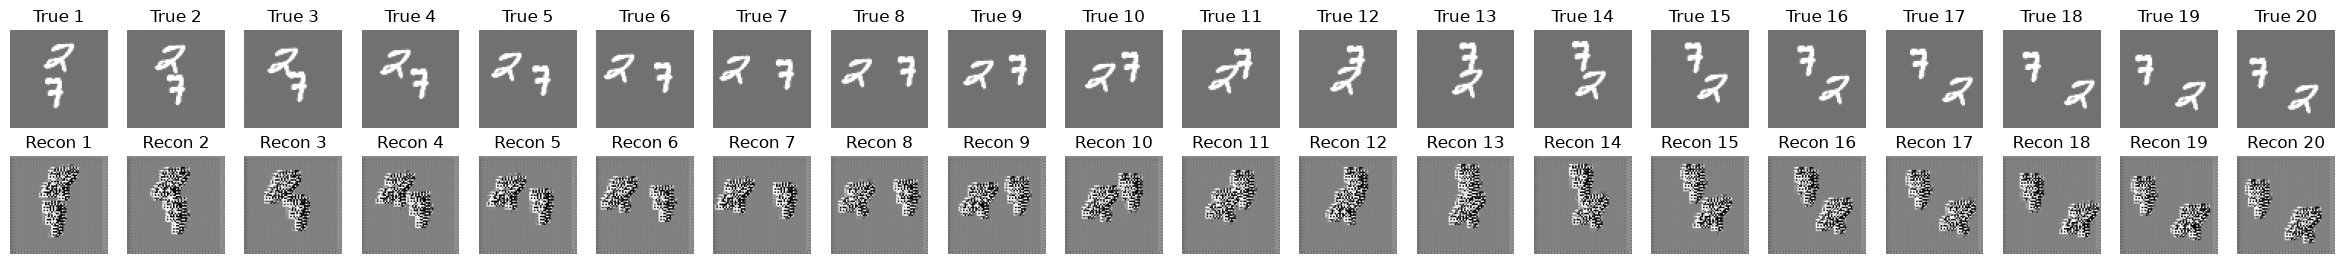

[A 001/015]  L_recon=0.09119  L_slow_raw=0.61356  λL_slow=0.12271  recon MSE=0.113035
[A 002/015]  L_recon=0.07726  L_slow_raw=0.59858  λL_slow=0.11972  recon MSE=0.092913
[A 003/015]  L_recon=0.06832  L_slow_raw=0.58380  λL_slow=0.11676  recon MSE=0.081390
[A 004/015]  L_recon=0.06304  L_slow_raw=0.57010  λL_slow=0.11402  recon MSE=0.074578
[A 005/015]  L_recon=0.05936  L_slow_raw=0.55749  λL_slow=0.11150  recon MSE=0.069644


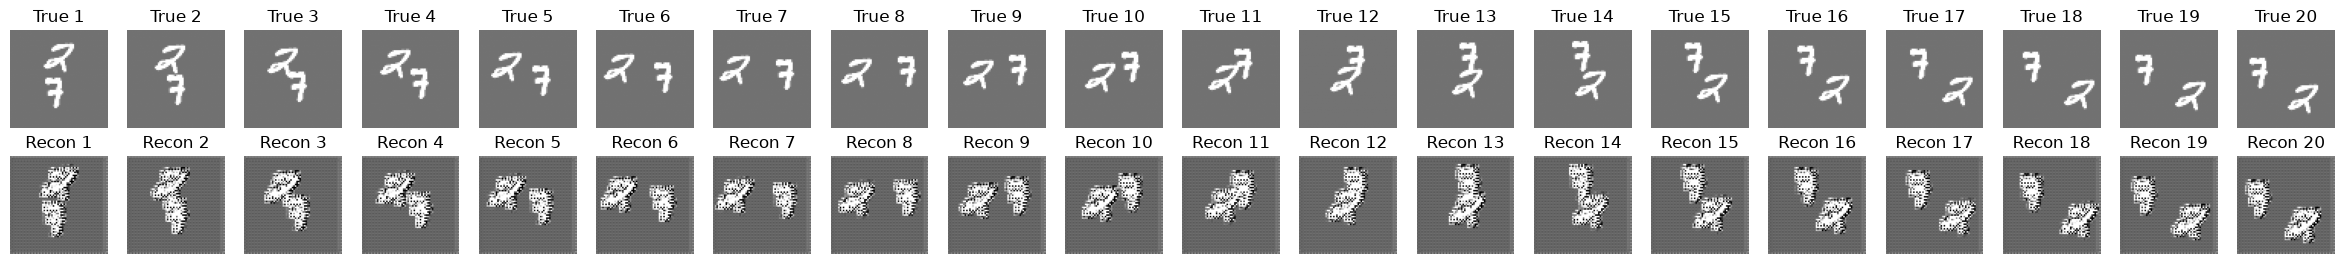

[A 006/015]  L_recon=0.05640  L_slow_raw=0.54584  λL_slow=0.10917  recon MSE=0.065803
[A 007/015]  L_recon=0.05384  L_slow_raw=0.53504  λL_slow=0.10701  recon MSE=0.062524
[A 008/015]  L_recon=0.05152  L_slow_raw=0.52501  λL_slow=0.10500  recon MSE=0.059536
[A 009/015]  L_recon=0.04938  L_slow_raw=0.51568  λL_slow=0.10314  recon MSE=0.056847
[A 010/015]  L_recon=0.04739  L_slow_raw=0.50700  λL_slow=0.10140  recon MSE=0.054387


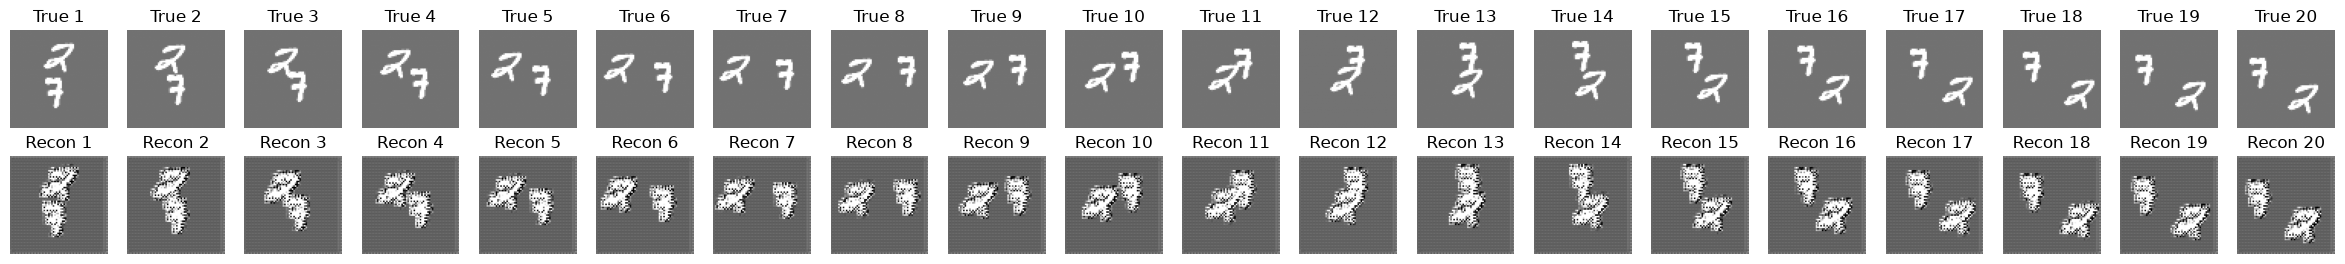

[A 011/015]  L_recon=0.04551  L_slow_raw=0.49891  λL_slow=0.09978  recon MSE=0.052118
[A 012/015]  L_recon=0.04376  L_slow_raw=0.49137  λL_slow=0.09827  recon MSE=0.050054
[A 013/015]  L_recon=0.04212  L_slow_raw=0.48433  λL_slow=0.09687  recon MSE=0.048118
[A 014/015]  L_recon=0.04057  L_slow_raw=0.47776  λL_slow=0.09555  recon MSE=0.046312


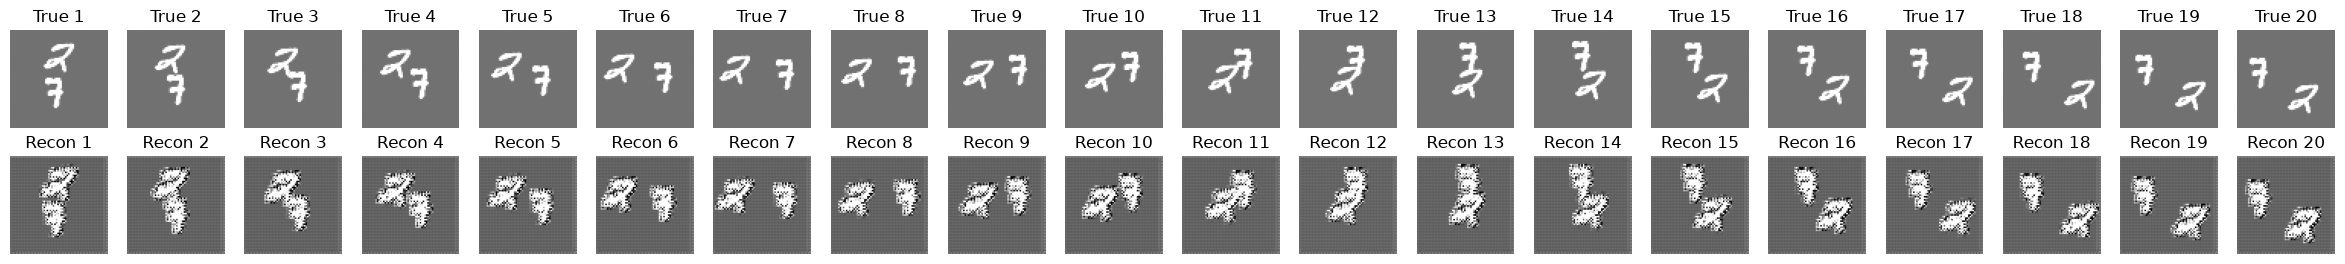


B. Latent smoothness [after stage A]
Same-frame cos=1.0000  (must be 1.0)

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.4506          1.0448     47.7682
   2          0.4863          1.0177     46.1550
   3          0.4906          1.0120     45.6607
   4          0.4333          1.0639     48.0710
   5          0.4770          1.0230     46.2024
   6          0.6175          0.8754     39.4688
   7          0.3551          1.1357     51.2064
   8          0.4087          1.0859     49.0991
   9          0.3577          1.1300     51.4031
  10          0.3801          1.1177     50.4638
  11          0.4264          1.0764     48.1186
  12          0.4109          1.0739     49.0650
  13          0.4330          1.0708     48.3885
  14          0.3978          1.0974     49.5951
  15          0.3915          1.0969     50.1496
  16          0.3700          1.1333     50.8472
  17          0.3541          1.1332     51.1442
  18          0.4484          1.0490     4

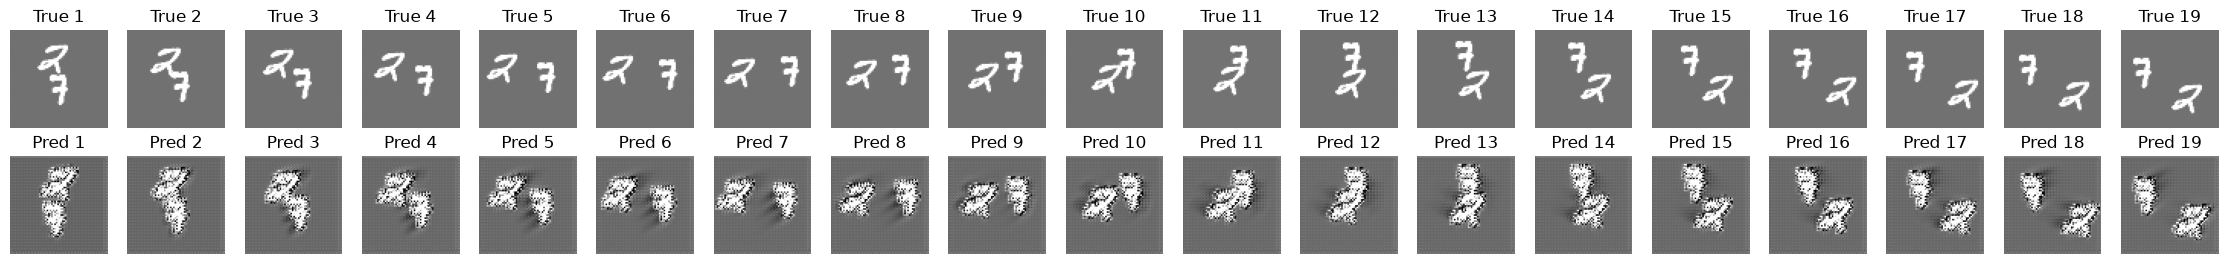

Identity check | ||delta||=18.369187  ||r_t-r_(t-1)||=66.932946  ratio=0.2744  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.067192  MSE(pred,true_(t-1))=0.046892  gap=+0.020300  COPY
[B 001/020]  r_noise=0.0026  ss_p=0.021  Next-frame MSE: 0.067192  train_δ-ratio=0.2457  val_δ-ratio=0.2744
Identity check | ||delta||=23.956928  ||r_t-r_(t-1)||=66.932946  ratio=0.3579  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.063651  MSE(pred,true_(t-1))=0.053682  gap=+0.009969  COPY
[B 002/020]  r_noise=0.0053  ss_p=0.042  Next-frame MSE: 0.063651  train_δ-ratio=0.3392  val_δ-ratio=0.3579
Identity check | ||delta||=27.672082  ||r_t-r_(t-1)||=66.932946  ratio=0.4134  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.061592  MSE(pred,true_(t-1))=0.058296  gap=+0.003296  COPY
[B 003/020]  r_noise=0.0079  ss_p=0.063  Next-frame MSE: 0.061592  train_δ-ratio=0.4013  val_δ-ratio=0.4134
Identity check | ||delta||=29.971655  ||r_t-r_(t-1)||=66.932946  ratio=0.4478  delta_scale=1.0
Copy-las

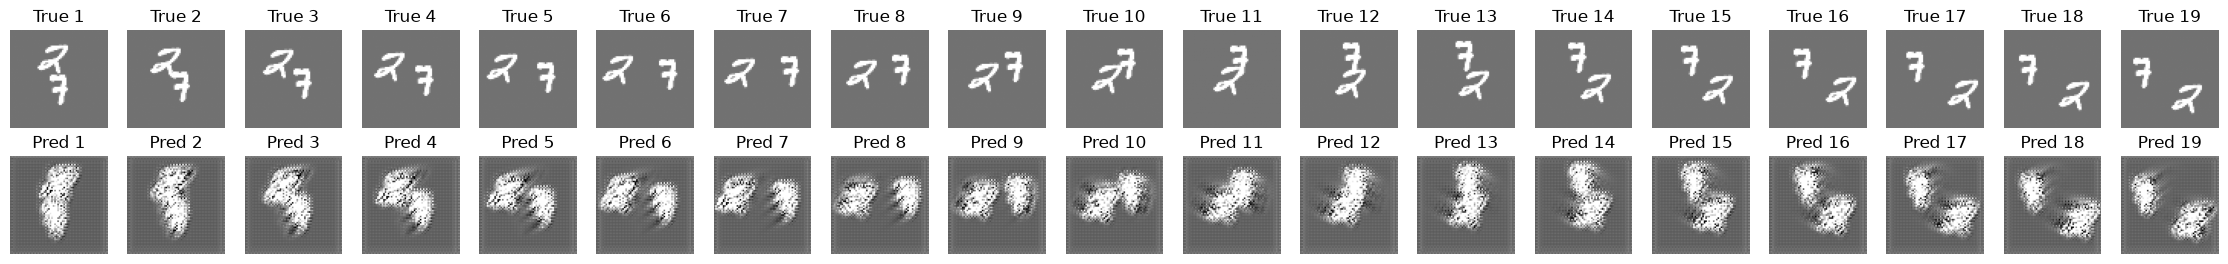

Identity check | ||delta||=32.993772  ||r_t-r_(t-1)||=66.932946  ratio=0.4929  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.058074  MSE(pred,true_(t-1))=0.061340  gap=-0.003266  MOTION
[B 006/020]  r_noise=0.0158  ss_p=0.126  Next-frame MSE: 0.058074  train_δ-ratio=0.4921  val_δ-ratio=0.4929
Identity check | ||delta||=34.001687  ||r_t-r_(t-1)||=66.932946  ratio=0.5080  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.057290  MSE(pred,true_(t-1))=0.060929  gap=-0.003639  MOTION
[B 007/020]  r_noise=0.0184  ss_p=0.147  Next-frame MSE: 0.057290  train_δ-ratio=0.5036  val_δ-ratio=0.5080
Identity check | ||delta||=34.809213  ||r_t-r_(t-1)||=66.932946  ratio=0.5201  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.056747  MSE(pred,true_(t-1))=0.060668  gap=-0.003922  MOTION
[B 008/020]  r_noise=0.0211  ss_p=0.168  Next-frame MSE: 0.056747  train_δ-ratio=0.5050  val_δ-ratio=0.5201
Identity check | ||delta||=35.597544  ||r_t-r_(t-1)||=66.932946  ratio=0.5318  delta_scale=1.0
Co

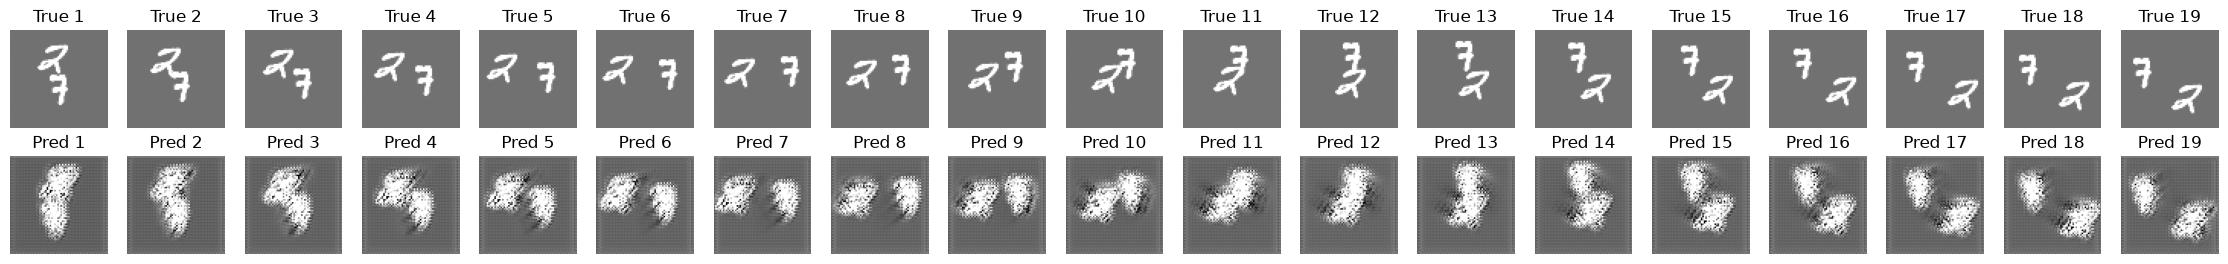

Identity check | ||delta||=36.592946  ||r_t-r_(t-1)||=66.932946  ratio=0.5467  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.055063  MSE(pred,true_(t-1))=0.058956  gap=-0.003894  MOTION
[B 011/020]  r_noise=0.0289  ss_p=0.232  Next-frame MSE: 0.055063  train_δ-ratio=0.5263  val_δ-ratio=0.5467
Identity check | ||delta||=37.008641  ||r_t-r_(t-1)||=66.932946  ratio=0.5529  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.054735  MSE(pred,true_(t-1))=0.058693  gap=-0.003959  MOTION
[B 012/020]  r_noise=0.0316  ss_p=0.253  Next-frame MSE: 0.054735  train_δ-ratio=0.5195  val_δ-ratio=0.5529
Identity check | ||delta||=37.483150  ||r_t-r_(t-1)||=66.932946  ratio=0.5600  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.054578  MSE(pred,true_(t-1))=0.058577  gap=-0.003999  MOTION
[B 013/020]  r_noise=0.0342  ss_p=0.274  Next-frame MSE: 0.054578  train_δ-ratio=0.5169  val_δ-ratio=0.5600
Identity check | ||delta||=37.862407  ||r_t-r_(t-1)||=66.932946  ratio=0.5657  delta_scale=1.0
Co

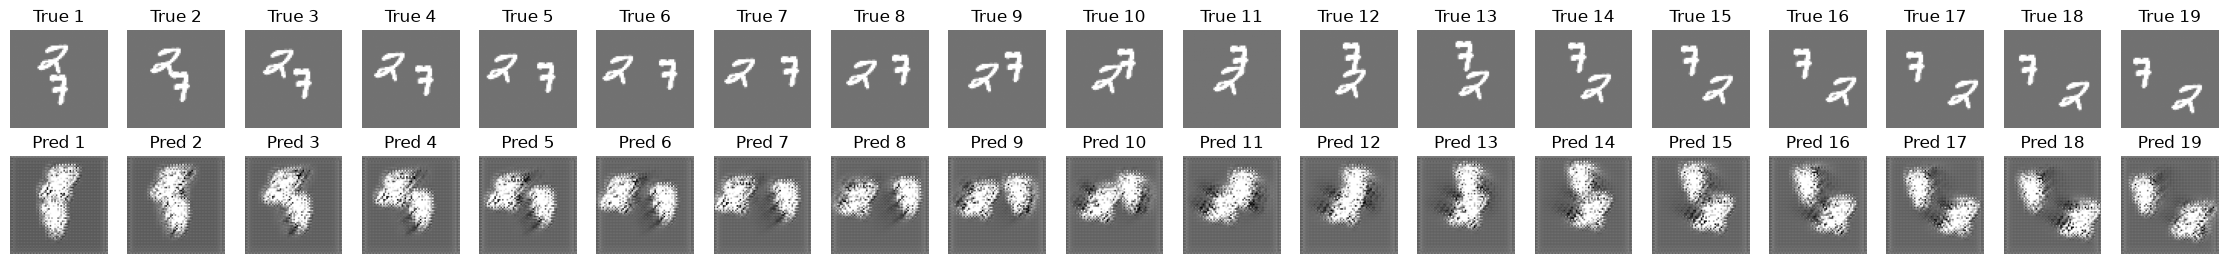

Identity check | ||delta||=38.608864  ||r_t-r_(t-1)||=66.932946  ratio=0.5768  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.054445  MSE(pred,true_(t-1))=0.058972  gap=-0.004527  MOTION
[B 016/020]  r_noise=0.0421  ss_p=0.337  Next-frame MSE: 0.054445  train_δ-ratio=0.5176  val_δ-ratio=0.5768
Identity check | ||delta||=38.955082  ||r_t-r_(t-1)||=66.932946  ratio=0.5820  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.053997  MSE(pred,true_(t-1))=0.058879  gap=-0.004881  MOTION
[B 017/020]  r_noise=0.0447  ss_p=0.358  Next-frame MSE: 0.053997  train_δ-ratio=0.5064  val_δ-ratio=0.5820
Identity check | ||delta||=39.158463  ||r_t-r_(t-1)||=66.932946  ratio=0.5850  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.053888  MSE(pred,true_(t-1))=0.058732  gap=-0.004843  MOTION
[B 018/020]  r_noise=0.0474  ss_p=0.379  Next-frame MSE: 0.053888  train_δ-ratio=0.5009  val_δ-ratio=0.5850
Identity check | ||delta||=39.666473  ||r_t-r_(t-1)||=66.932946  ratio=0.5926  delta_scale=1.0
Co

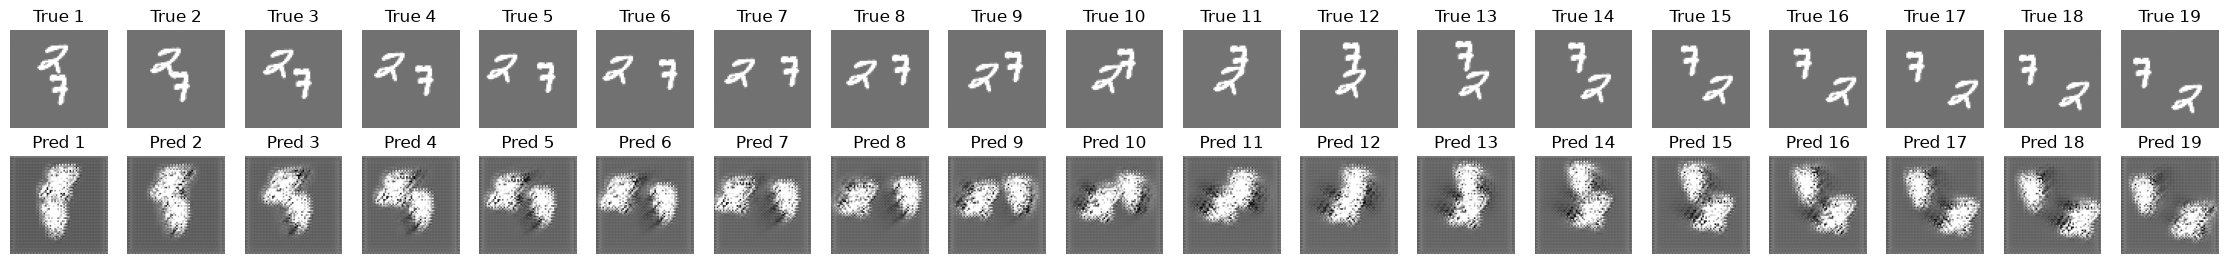


Post-train latent smoothness (frozen encoder):

B. Latent smoothness [after stage B]
Same-frame cos=1.0000  (must be 1.0)

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.4506          1.0448     47.7682
   2          0.4863          1.0177     46.1550
   3          0.4906          1.0120     45.6607
   4          0.4333          1.0639     48.0710
   5          0.4770          1.0230     46.2024
   6          0.6175          0.8754     39.4688
   7          0.3551          1.1357     51.2064
   8          0.4087          1.0859     49.0991
   9          0.3577          1.1300     51.4031
  10          0.3801          1.1177     50.4638
  11          0.4264          1.0764     48.1186
  12          0.4109          1.0739     49.0650
  13          0.4330          1.0708     48.3885
  14          0.3978          1.0974     49.5951
  15          0.3915          1.0969     50.1496
  16          0.3700          1.1333     50.8472
  17          0.3541          1.1332     51

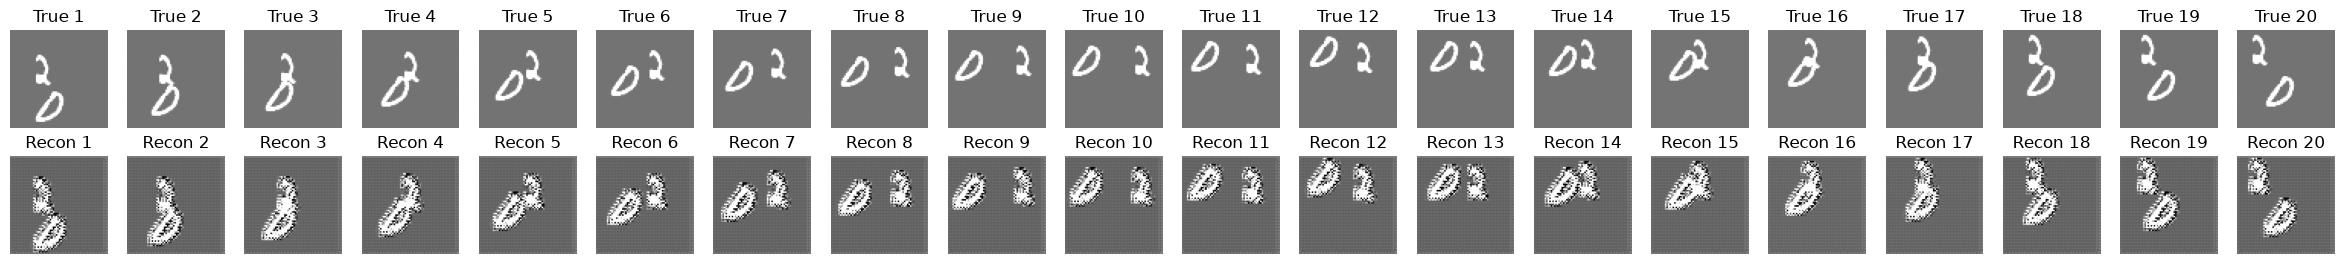

Identity check | ||delta||=39.265930  ||r_t-r_(t-1)||=67.925577  ratio=0.5781  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.052870  MSE(pred,true_(t-1))=0.053099  gap=-0.000229  MOTION
Validation  ->  Next-frame MSE: 0.052870  δ-ratio=0.5781  |  Per-frame: ['0.0617', '0.0516', '0.0483', '0.0539', '0.0565', '0.0522', '0.0547', '0.0565', '0.0530', '0.0625', '0.0574', '0.0580', '0.0491', '0.0492', '0.0482', '0.0418', '0.0479', '0.0490', '0.0531']


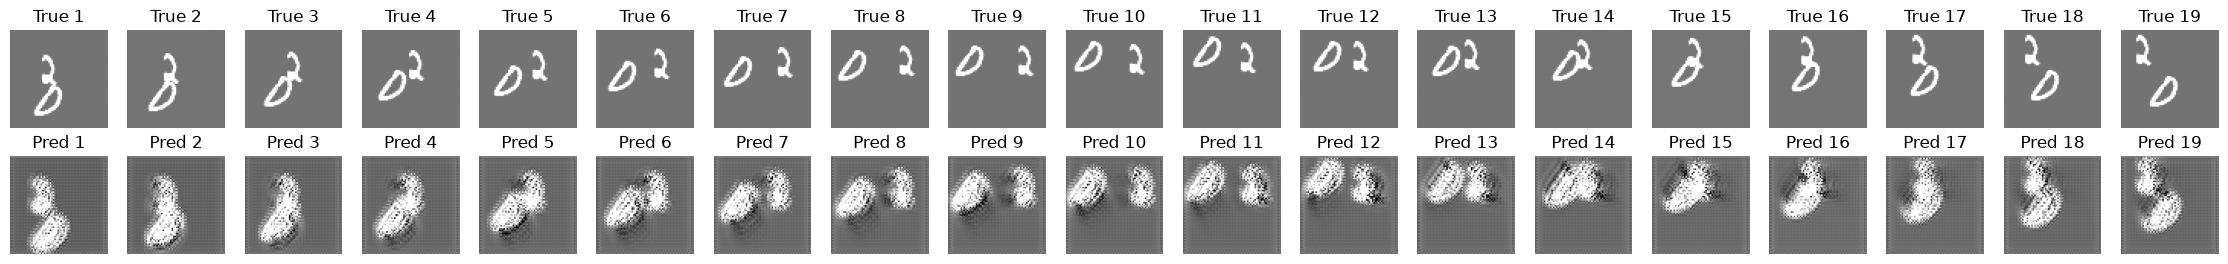

t=10 saturation | true: 0.0000 | substitute: 0.0139
Long-run  ->  MSE: 0.347470  |  Per-frame: ['0.0617', '0.0516', '0.0483', '0.0539', '0.0565', '0.0522', '0.0547', '0.0565', '0.0530', '0.0625', '0.1428', '0.2731', '0.4710', '0.6923', '0.8042', '0.8683', '0.9098', '0.9264', '0.9631']


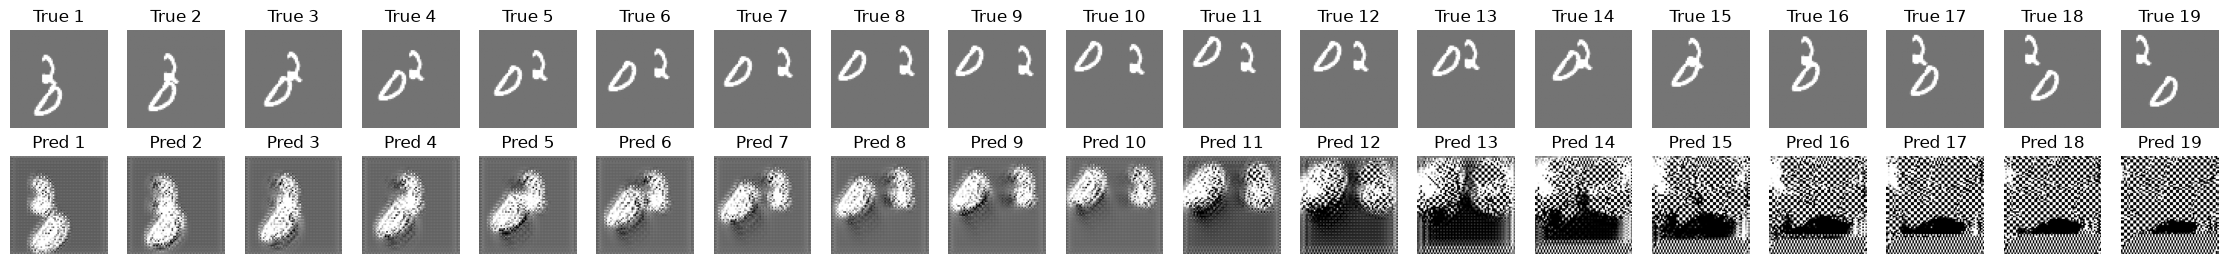

In [23]:
if __name__ == "__main__":
    main()
